<a href="https://colab.research.google.com/github/vis-hal-git/Brain-Tumer-prediction/blob/main/Model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

img_size = 224
batch_size = 32

train_dir = os.path.join(path, "Training")
val_dir  = os.path.join(path, "Testing")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50

def build_model(base_model):
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model = build_model(base_model)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 123s 618ms/step - accuracy: 0.4346 - loss: 1.2011 - val_accuracy: 0.3925 - val_loss: 1.2543 - learning_rate: 1.0000e-04
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 471ms/step - accuracy: 0.5489 - loss: 1.0315 - val_accuracy: 0.5806 - val_loss: 1.1150 - learning_rate: 1.0000e-04
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 472ms/step - accuracy: 0.6005 - loss: 0.9547 - val_accuracy: 0.6169 - val_loss: 1.1172 - learning_rate: 1.0000e-04
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 472ms/step - accuracy: 0.5950 - loss: 0.9428 - val_accuracy: 0.6469 - val_loss: 1.0965 - learning_rate: 1.0000e-04
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 471ms/step - accuracy: 0.6195 - loss: 0.9113 - val_accuracy: 0.6569 - val_loss: 1.0828 - learning_rate: 1.0000e-04
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 82s 471ms/step - accuracy: 0.6186 - loss: 0.9034 - val_accuracy: 0.6475 - val_loss: 1.1471 - learning_rate: 1.0000e-04
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 4

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 523ms/step - accuracy: 0.5023 - loss: 1.4553 - val_accuracy: 0.2875 - val_loss: 4.1329
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 84s 477ms/step - accuracy: 0.5857 - loss: 1.0876 - val_accuracy: 0.3994 - val_loss: 1.6271
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 477ms/step - accuracy: 0.6089 - loss: 0.9487 - val_accuracy: 0.6675 - val_loss: 1.2683
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 474ms/step - accuracy: 0.6404 - loss: 0.9110 - val_accuracy: 0.6706 - val_loss: 1.2968
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 84s 481ms/step - accuracy: 0.6543 - loss: 0.8362 - val_accuracy: 0.6975 - val_loss: 1.3023
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 82s 467ms/step - accuracy: 0.6529 - loss: 0.8675 - val_accuracy: 0.6694 - val_loss: 1.1693
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 84s 482ms/step - accuracy: 0.6564 - loss: 0.8030 - val_accuracy: 0.6888 - val_loss: 1.1886
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 485ms/step - accuracy: 0.6687 - loss: 

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step
              precision    recall  f1-score   support

           0       0.73      0.46      0.57       400
           1       0.66      0.37      0.47       400
           2       0.74      0.96      0.84       400
           3       0.64      0.98      0.78       400

    accuracy                           0.69      1600
   macro avg       0.70      0.69      0.66      1600
weighted avg       0.70      0.69      0.66      1600



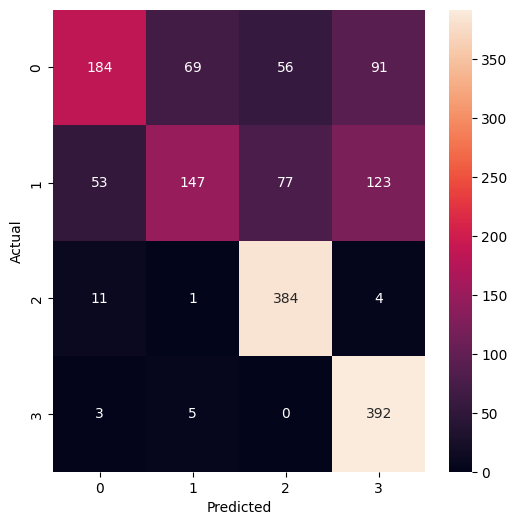

In [ ]:
val_gen.reset()
pred = model.predict(val_gen)
y_pred = np.argmax(pred, axis=1)

print(classification_report(val_gen.classes, y_pred))

cm = confusion_matrix(val_gen.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()